In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("UMAP не установлен")

In [10]:
import os

path_to_data = '../../data/TRAINING_DATASET.csv'
if(os.path.exists(path_to_data)==False):
    print(f"Файл не найден по указанному пути: {path_to_data}")
else:
    df = pd.read_csv(path_to_data)# бёрем файл для датасета с полями text,processed_text,label
    texts = df['processed_text'].fillna('')

    vectorizer = TfidfVectorizer(max_features=2000, min_df=5, max_df=0.95)
    X = vectorizer.fit_transform(texts)

    # X_dense = X.toarray() # раскомментировать если потребуется плотная, а не разреженная матрица
    print(f"Размерность матрицы: {X.shape}")

Размерность матрицы: (45842, 507)


Запуск анализа локтевого метода...


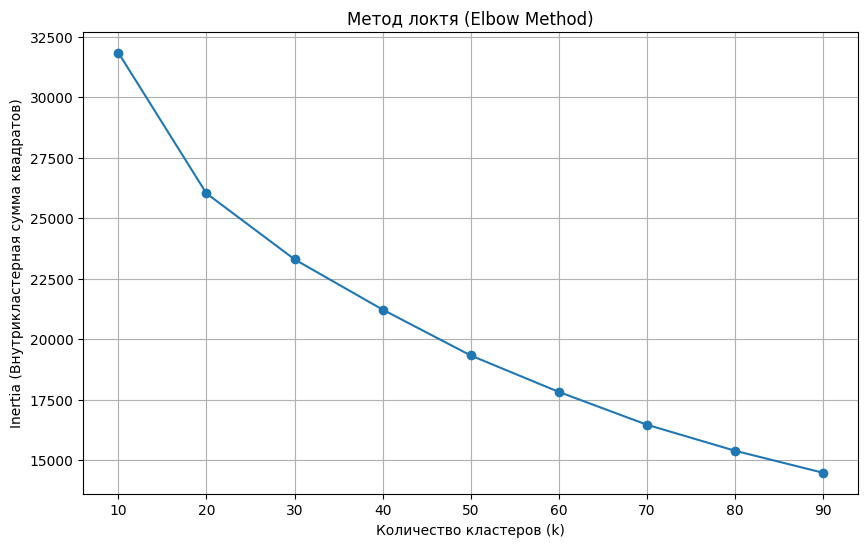

In [11]:
inertia = []
K_range = range(10, 100, 10) #проверка от 10 до 90 кластеров с шагом 10

print("Запуск анализа локтевого метода...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Inertia (Внутрикластерная сумма квадратов)')
plt.title('Метод локтя (Elbow Method)')
plt.grid(True)
plt.show()

In [12]:
k_best = 30
kmeans = KMeans(n_clusters=k_best, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X)

print(f"--- Метрики качества кластеризации (k={k_best}) ---")

# 1. Силуэт (Silhouette Score)
# Диапазон [-1, 1]. Чем ближе к 1, тем лучше. Около 0 - кластеры накладываются.
# Считаем на подвыборке из 5000, иначе будет очень долго!
from sklearn.utils import resample
X_sample, labels_sample = resample(X, labels, n_samples=5000, random_state=42)

sil_score = silhouette_score(X_sample, labels_sample, metric='cosine')
print(f"Silhouette Score: {sil_score:.4f} (Чем выше, тем лучше)")

# 2. Индекс Калински-Харабаса
ch_score = calinski_harabasz_score(X_sample.toarray(), labels_sample)
print(f"Calinski-Harabasz Score: {ch_score:.2f} (Чем выше, тем лучше)")

# 3. Индекс Дэвиса-Болдина
db_score = davies_bouldin_score(X_sample.toarray(), labels_sample)
print(f"Davies-Bouldin Score: {db_score:.4f} (Чем НИЖЕ, тем лучше)")

--- Метрики качества кластеризации (k=30) ---
Silhouette Score: 0.3194 (Чем выше, тем лучше)
Calinski-Harabasz Score: 131.36 (Чем выше, тем лучше)
Davies-Bouldin Score: 2.1898 (Чем НИЖЕ, тем лучше)


Начат процесс визуализации...


  0%|          | 0/3 [00:00<?, ?it/s]

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.001s...
[t-SNE] Computed neighbors for 5000 samples in 0.131s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 62.745956
[t-SNE] KL divergence after 1000 iterations: 0.279071


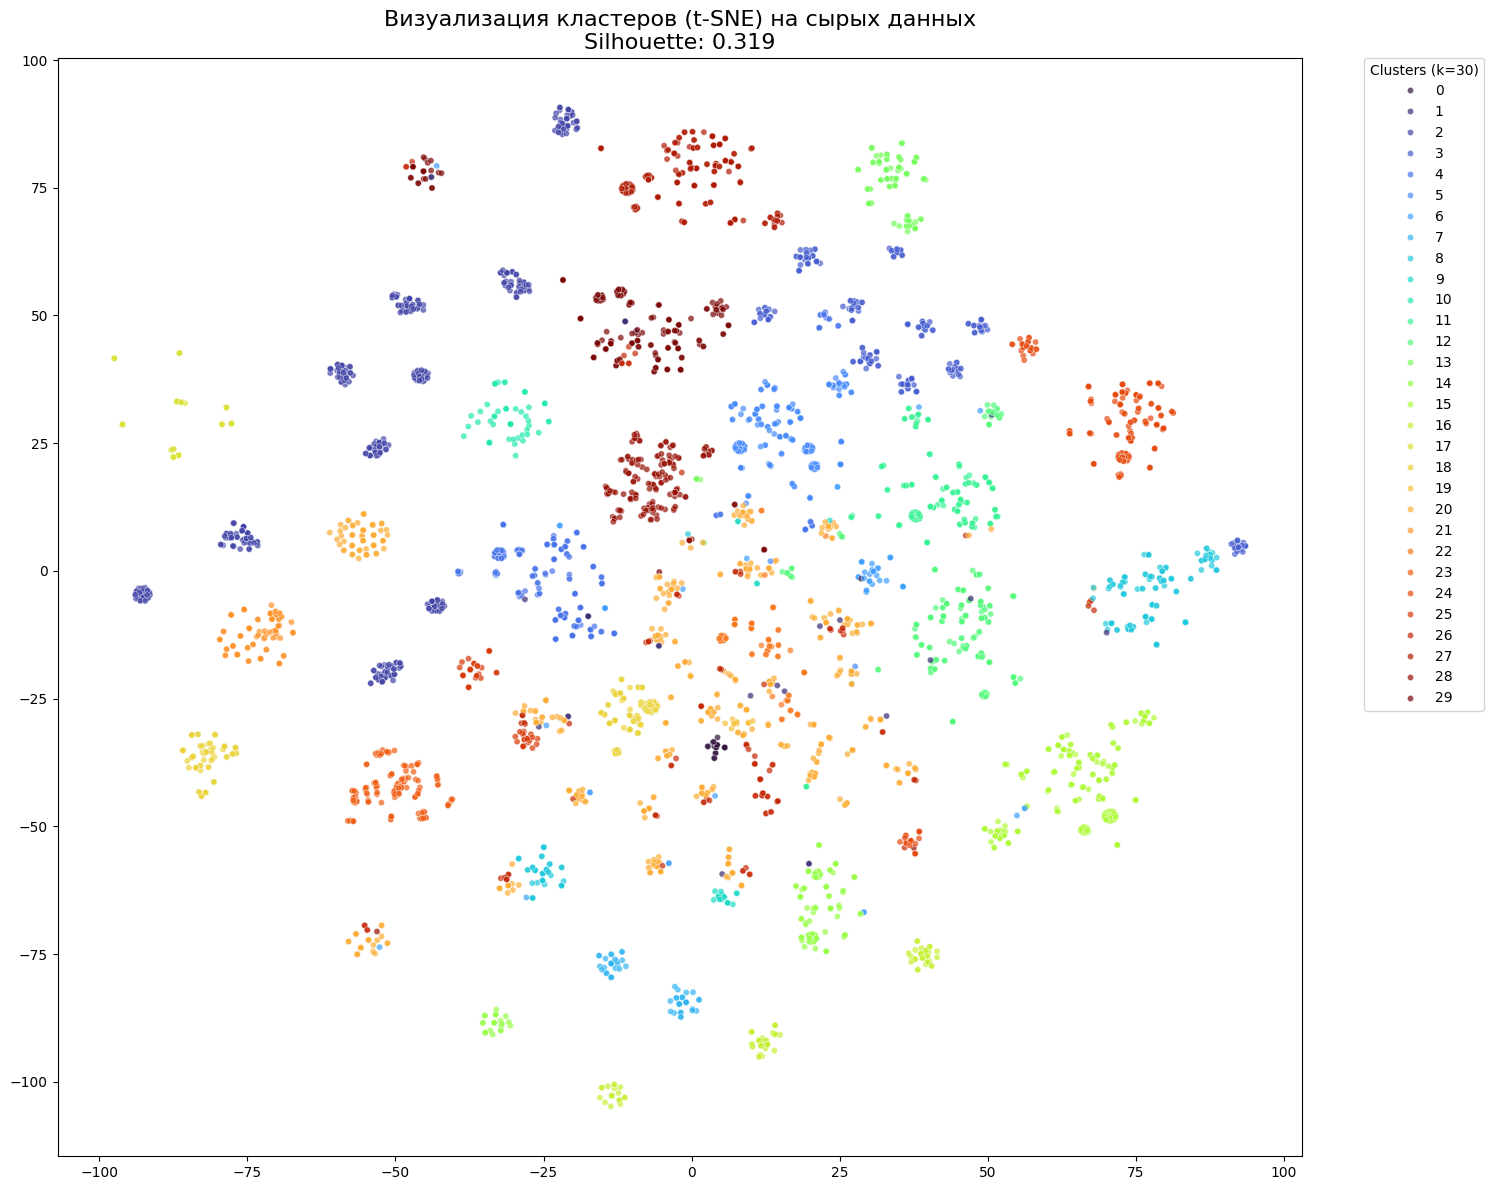

In [13]:
from tqdm.notebook import tqdm
import time

print("Начат процесс визуализации...")

# Список задач, чтобы работал прогресс-бар
steps = ["PCA (Понижение размерности)", "t-SNE (Вычисление координат)", "Построение графика"]

with tqdm(total=len(steps)) as pbar:
    
    # ---PCA ---
    pbar.set_description(steps[0])
    # Снижаем до 50 компонент
    pca = PCA(n_components=50, random_state=42)
    X_pca = pca.fit_transform(X_sample.toarray())
    pbar.update(1)
    time.sleep(0.5) # Небольшая пауза, чтобы бар успел обновиться визуально

    # t-SNE ---
    pbar.set_description(steps[1])
    # verbose=1 все равно будет писать логи под ячейкой
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, verbose=1)
    X_embedded = tsne.fit_transform(X_pca)
    pbar.update(1)

    pbar.set_description(steps[2])
    plt.figure(figsize=(15, 12))
    
    sns.scatterplot(
        x=X_embedded[:, 0], 
        y=X_embedded[:, 1], 
        hue=labels_sample, 
        palette="turbo", # Яркая палитра, где хорошо видно много групп
        legend="full",
        s=20,            # Размер точек
        alpha=0.7        # Прозрачность
    )
    
    # Настройка легенды, чтобы она не перекрывала график (выносим вбок)
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title=f"Clusters (k={k_best})")
    plt.title(f'Визуализация кластеров (t-SNE) на сырых данных\nSilhouette: {sil_score:.3f}', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    pbar.update(1)
    pbar.set_description("Процесс визуализации завершён")

In [14]:
print("--- Топ слова в кластерах ---")
# Получаем центры кластеров
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(30):
    print(f"Cluster {i}: ", end='')
    top_terms = [terms[ind] for ind in order_centroids[i, :7]] # Топ-7 слов
    print(", ".join(top_terms))

--- Топ слова в кластерах ---
Cluster 0: код, шар, запись, файловый, ошибка, назначать, группа
Cluster 1: платежный, система, группа, назначать, авария, иса, описание
Cluster 2: коллега, контур, куратор, аварийный, просьба, подключаться, конференция
Cluster 3: зни, список, отправлять, почтовый, сообщение, тип, целевой
Cluster 4: ов, падение, перезапускаться, перезапускать, авария, иса, описание
Cluster 5: состояние, останавливать, сервис, репликация, авария, иса, назначать
Cluster 6: телеком, сеть, назначать, группа, авария, иса, описание
Cluster 7: метрика, отклонение, обновление, мина, узел, отсутствовать, хост
Cluster 8: нагрузка, замечать, отклик, замедление, высокий, сервис, авария
Cluster 9: время, отклик, превышать, назначать, группа, иса, авария
Cluster 10: широкомасштабный, минута, ке, подозрение, сбой, авария, опис
Cluster 11: сечь, хост, репликация, ошибка, авария, иса, описание
Cluster 12: недоступность, авторизация, обращение, авария, иса, описание, назначать
Cluster 13: з